### Project: Laptop Price Predictor

**Objective:** To build a machine learning model that predicts laptop prices based on technical specifications.

* **Dataset Source:** Provided locally within the project folder.
* **Goal:** Compare the performance of:
    * Linear Regression
    * Random Forest Regressor
    * Decision Tree Regressor

In [28]:
# Import Libraries
import pandas as pd
import numpy as np

# Load the Dataset
df = pd.read_csv('./data/laptop_data.csv')

In [29]:
# Check the first few() rows of dataset
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [30]:
# 1. Basic Info (Check data types and non-null counts)
print("----Data Info----")
df.info()

print("-" * 50)

# Check Missing values
print("\n---Missing Values Count---")
print(df.isnull().sum())

print("-" * 50)

# 3. Statistical Summary (Mean, Min, Max, etc.)
print("\n---Statistical Summary ---")
print(df.describe())

print("-" * 50)

# 4. Check for Duplicates
print(f"\n Duplicate Values: {df.duplicated().sum()}")

----Data Info----
<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               1303 non-null   str    
 7   Memory            1303 non-null   str    
 8   Gpu               1303 non-null   str    
 9   OpSys             1303 non-null   str    
 10  Weight            1303 non-null   str    
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 261.0 KB
--------------------------------------------------

---Missing Values Count---
Unnamed: 0          0
Company             0
TypeName            0
Inches              0
S

### Project: Laptop Price Predictor
* The dataset consist of 1303 entries. The data has no missing values and no duplicated records, here we are good to go.

* In dataset, the stats show high variance due to huge differences of price ranges 9270 to 324954. It shows significant variance (Std Dev: 37,243), indicating a diverse range of hardware tiers.

* The median price (52,054) is lower than the mean (59,870), which confirms the presence of "premium" laptops pulling the average price upward. In this sense, the data is skewed.

* Let's see our data skewness through data visualization.



### Visual Exploration (EDA)

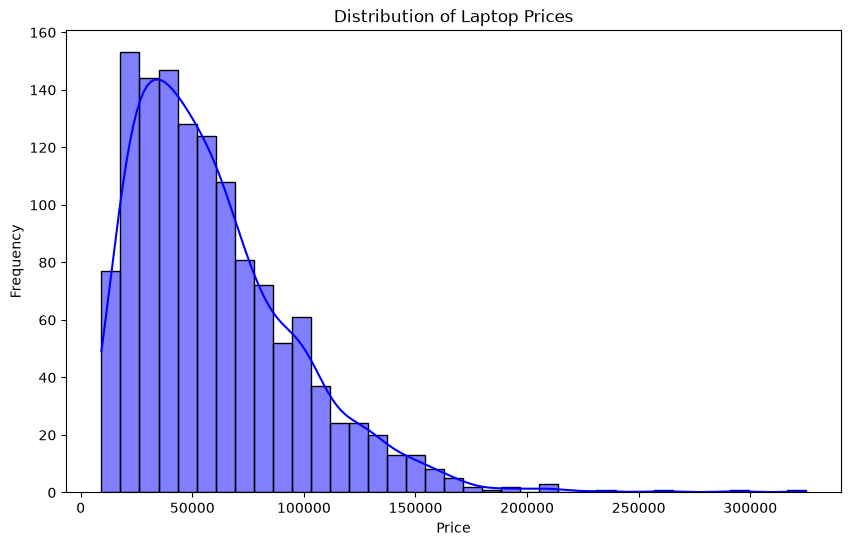

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of prices to visualize that "Premium" tail
plt.figure(figsize=(10,6))
sns.histplot(df['Price'], kde=True, color="blue")
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Preprocessing & Feature Engineering
#### 1. Normalize Skewed Data
* We will apply Log Transformation, as data will become Bell-Shaped


<Axes: xlabel='Price', ylabel='Count'>

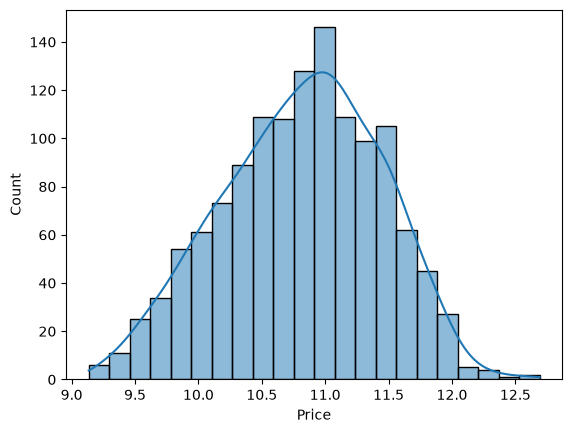

In [32]:
# Apply Log transformation to the target variable
df['Price']  = np.log(df['Price'])

# Now the distribution will look much more "Normal" (bell-shaped)
sns.histplot(df['Price'], kde=True)

* Now we can see that by applying log transformation on our Price feature, the Price data is now bell-shaped instead right skewness.

#### 2. Cleaning Numerical Features (Ram & Weight)

In [33]:
# 1. Clean 'Ram' column
# Remove 'GB' and convert to integer
df['Ram'] = df['Ram'].str.replace('GB', '').astype('int32')

# 2. Clean 'Weight' column
# Remove 'kg' and convert to float
df['Weight'] = df['Weight'].str.replace('kg', '').astype('float64')

# Verify the Changes
print(df[['Ram', 'Weight']].info())

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ram     1303 non-null   int32  
 1   Weight  1303 non-null   float64
dtypes: float64(1), int32(1)
memory usage: 15.4 KB
None


#### 3. Clean the "Memory" Column and separate "SSD" & "HDD"

In [34]:
# 1. Clean and Split
new = df['Memory'].str.split("+", n=1, expand=True)
df['first'] = new[0].str.strip()
df['second'] = new[1].str.strip().fillna("0")

# 2. PERFORM FLAGS (Identify everything)
df['Layer1HDD'] = df['first'].apply(lambda x: 1 if "HDD" in x else 0)
df['Layer1SSD'] = df['first'].apply(lambda x: 1 if "SSD" in x else 0)
df['Layer1Flash'] = df['first'].apply(lambda x: 1 if "Flash" in x else 0)

df['Layer2HDD'] = df['second'].apply(lambda x: 1 if "HDD" in x else 0)
df['Layer2SSD'] = df['second'].apply(lambda x: 1 if "SSD" in x else 0)
df['Layer2Flash'] = df['second'].apply(lambda x: 1 if "Flash" in x else 0)

# 3. Convert only the numbers
df['first'] = df['first'].str.replace(r'\D', '', regex=True).astype(int)
df['second'] = df['second'].str.replace(r'\D', '', regex=True).astype(int)

# 4. Final Calculation
# HDD: Just check HDD layers
df['HDD'] = (df['first'] * df['Layer1HDD'] + df['second'] * df['Layer2HDD'])

# SSD: Check BOTH SSD layers AND Flash layers
df['SSD'] = (df['first'] * df['Layer1SSD'] + df['second'] * df['Layer2SSD'] +
             df['first'] * df['Layer1Flash'] + df['second'] * df['Layer2Flash'])

# 5. Clean up helper columns
df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Flash',
                 'Layer2HDD', 'Layer2SSD', 'Layer2Flash', 'Memory'], inplace=True)

In [35]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               1303 non-null   int32  
 7   Gpu               1303 non-null   str    
 8   OpSys             1303 non-null   str    
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  HDD               1303 non-null   int64  
 12  SSD               1303 non-null   int64  
dtypes: float64(3), int32(1), int64(3), str(6)
memory usage: 241.2 KB
None
   Unnamed: 0 Company   TypeName  Inches                    ScreenResolution  \
0           0   Apple  Ultrabook    13.3  IP

In [36]:
# Run this specific command to check the rows that SHOULD have an HDD
print(df.loc[5:7, ['HDD', 'SSD']])

   HDD  SSD
5  500    0
6    0  256
7    0  256


#### 4.1.1 Extracting Touch Screen Features

In [37]:
# Create Touchscreen and IPS flags
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

# Extract Resolution X and Y
new_res = df['ScreenResolution'].str.split('x', n=1, expand=True)
df['X_res'] = new_res[0].str.findall(r'(\d+\.?\d+)').apply(lambda x: x[0]).astype('int')
df['Y_res'] = new_res[1].str.findall(r'(\d+\.?\d+)').apply(lambda x: x[0]).astype('int')

In [38]:
# Check the dataset after extracting new features
df.head(3)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Gpu,OpSys,Weight,Price,HDD,SSD,Touchscreen,IPS,X_res,Y_res
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,Intel Iris Plus Graphics 640,macOS,1.37,11.175755,0,128,0,1,2560,1600
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,Intel HD Graphics 6000,macOS,1.34,10.776777,0,128,0,0,1440,900
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,Intel HD Graphics 620,No OS,1.86,10.329931,0,256,0,0,1920,1080


#### 4.1.2 Calculate PPI and Cleanup

In [39]:
# Calculate PPI (Pixels Per Inch)
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5 / df['Inches']).astype('float')

# Drop the original column now that we have extracted all the data
df.drop(columns=['ScreenResolution'], inplace=True, errors='ignore')

# Final check
print(df.head())

   Unnamed: 0 Company   TypeName  Inches                         Cpu  Ram  \
0           0   Apple  Ultrabook    13.3        Intel Core i5 2.3GHz    8   
1           1   Apple  Ultrabook    13.3        Intel Core i5 1.8GHz    8   
2           2      HP   Notebook    15.6  Intel Core i5 7200U 2.5GHz    8   
3           3   Apple  Ultrabook    15.4        Intel Core i7 2.7GHz   16   
4           4   Apple  Ultrabook    13.3        Intel Core i5 3.1GHz    8   

                            Gpu  OpSys  Weight      Price  HDD  SSD  \
0  Intel Iris Plus Graphics 640  macOS    1.37  11.175755    0  128   
1        Intel HD Graphics 6000  macOS    1.34  10.776777    0  128   
2         Intel HD Graphics 620  No OS    1.86  10.329931    0  256   
3            AMD Radeon Pro 455  macOS    1.83  11.814476    0  512   
4  Intel Iris Plus Graphics 650  macOS    1.37  11.473101    0  256   

   Touchscreen  IPS  X_res  Y_res         ppi  
0            0    1   2560   1600  226.983005  
1            0

In [40]:
print(df['Cpu'])

0                       Intel Core i5 2.3GHz
1                       Intel Core i5 1.8GHz
2                 Intel Core i5 7200U 2.5GHz
3                       Intel Core i7 2.7GHz
4                       Intel Core i5 3.1GHz
                        ...                 
1298              Intel Core i7 6500U 2.5GHz
1299              Intel Core i7 6500U 2.5GHz
1300    Intel Celeron Dual Core N3050 1.6GHz
1301              Intel Core i7 6500U 2.5GHz
1302    Intel Celeron Dual Core N3050 1.6GHz
Name: Cpu, Length: 1303, dtype: str


#### 5.5.1 Extract CPU Name

In [41]:
# Create a new 'Cpu Name' column
df['Cpu Name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[0:3]))   # It will take first 3 words of each CPU name e.g. Intel Core i7
print(df['Cpu Name'].value_counts())

Cpu Name
Intel Core i7               527
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
AMD A6-Series 9220            8
Intel Celeron Quad            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
Intel Atom x5-Z8550           4
AMD A8-Series 7410            4
AMD Ryzen 1700                3
Intel Pentium Dual            3
AMD A9-Series 9410            3
AMD E-Series E2-9000e         2
Intel Xeon E3-1505M           2
AMD A10-Series A10-9620P      2
AMD A6-Series A6-9220         2
AMD A10-Series 9600P          2
AMD A10-Series 9620P          2
AMD E-Series 7110             2
AMD A9-Series A9-9420         2
Intel Xeon E3-1535M           2
Intel Atom X5-Z8350           2
Intel Atom x5-Z8300           1
AMD E-Series E2-6110          1
AMD FX 9830P                  1
AMD E-Series 6110             1
AMD E-Series 9000e            1

#### 5.1.2 Categorize CPU

In [42]:
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    elif text.split()[0] == 'Intel':
        return 'Other Intel Processor'
    else:
        return 'AMD Processor'

# Apply the function and drop the original 'Cpu' column
df['Cpu brand'] = df['Cpu Name'].apply(fetch_processor)
df.drop(columns=['Cpu', 'Cpu Name'], inplace=True)

# Final check
print(df.head())

   Unnamed: 0 Company   TypeName  Inches  Ram                           Gpu  \
0           0   Apple  Ultrabook    13.3    8  Intel Iris Plus Graphics 640   
1           1   Apple  Ultrabook    13.3    8        Intel HD Graphics 6000   
2           2      HP   Notebook    15.6    8         Intel HD Graphics 620   
3           3   Apple  Ultrabook    15.4   16            AMD Radeon Pro 455   
4           4   Apple  Ultrabook    13.3    8  Intel Iris Plus Graphics 650   

   OpSys  Weight      Price  HDD  SSD  Touchscreen  IPS  X_res  Y_res  \
0  macOS    1.37  11.175755    0  128            0    1   2560   1600   
1  macOS    1.34  10.776777    0  128            0    0   1440    900   
2  No OS    1.86  10.329931    0  256            0    0   1920   1080   
3  macOS    1.83  11.814476    0  512            0    1   2880   1800   
4  macOS    1.37  11.473101    0  256            0    1   2560   1600   

          ppi      Cpu brand  
0  226.983005  Intel Core i5  
1  127.677940  Intel Cor

#### 6. Cleaning OpSys Column

In [43]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'macOS'
    else:
        return 'Others/No OS/Linux'

# Apply the function
df['OpSys'] = df['OpSys'].apply(cat_os)

# Final check of the structure
print(df.head())

   Unnamed: 0 Company   TypeName  Inches  Ram                           Gpu  \
0           0   Apple  Ultrabook    13.3    8  Intel Iris Plus Graphics 640   
1           1   Apple  Ultrabook    13.3    8        Intel HD Graphics 6000   
2           2      HP   Notebook    15.6    8         Intel HD Graphics 620   
3           3   Apple  Ultrabook    15.4   16            AMD Radeon Pro 455   
4           4   Apple  Ultrabook    13.3    8  Intel Iris Plus Graphics 650   

                OpSys  Weight      Price  HDD  SSD  Touchscreen  IPS  X_res  \
0               macOS    1.37  11.175755    0  128            0    1   2560   
1               macOS    1.34  10.776777    0  128            0    0   1440   
2  Others/No OS/Linux    1.86  10.329931    0  256            0    0   1920   
3               macOS    1.83  11.814476    0  512            0    1   2880   
4               macOS    1.37  11.473101    0  256            0    1   2560   

   Y_res         ppi      Cpu brand  
0   1600  22

In [44]:
# 0. Drop the index column if it exists
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Save the dataset after cleaning it
df.to_csv('./data/cleaned_data.csv', index=False)

# Load the cleaned dataset
df_cleaned = pd.read_csv('./data/cleaned_data.csv')

# See the dataset after cleaning
df_cleaned.head()

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,HDD,SSD,Touchscreen,IPS,X_res,Y_res,ppi,Cpu brand
0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37,11.175755,0,128,0,1,2560,1600,226.983005,Intel Core i5
1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34,10.776777,0,128,0,0,1440,900,127.677940,Intel Core i5
2,HP,Notebook,15.6,8,Intel HD Graphics 620,Others/No OS/Linux,1.86,10.329931,0,256,0,0,1920,1080,141.211998,Intel Core i5
3,Apple,Ultrabook,15.4,16,AMD Radeon Pro 455,macOS,1.83,11.814476,0,512,0,1,2880,1800,220.534624,Intel Core i7
4,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 650,macOS,1.37,11.473101,0,256,0,1,2560,1600,226.983005,Intel Core i5


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. Define your features (X) and target (y)
X = df_cleaned.drop(columns=['Price'])
y = df_cleaned['Price'] # Use the Log-transformed price here!

# 2. X is features, y is target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Automatically Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include= ['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['object', 'str']).columns

# 4. Create a transformer to handle both numerical & categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# 5. Create a Pipeline
# This chains the preprocessor AND the model together
pipeline = Pipeline(steps=[
    ('Preprocessor', preprocessor),
    ('Model', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6,  random_state=42))
])

# 6. Train the whole thing at once
# This fits the scaler/encoder on X_train ONLY, then fits the model
pipeline.fit(X_train, y_train)

# 7. Predict on test set
# This automatically applies the scaling/encoding learned from train to X_test
y_pred = pipeline.predict(X_test)

#### 7. Model Evaluation

In [46]:
# Import Libraries
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# Print the Evaluation Matrix
print(f"R2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

R2 Score: 0.8727842912631798
Mean Absolute Error: 0.15249209561027932
Root Mean Squared Error: 0.21233989398554604


#### 8. Improve Model Result By Using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Define the search space
# (We use 'Model__' prefix to tell the grid to look inside the pipeline)
param_grid = {
    'Model__n_estimators': [100, 200, 500],
    'Model__learning_rate': [0.01, 0.1, 0.2],
    'Model__max_depth': [3, 6, 9]
}

# 2. Setup the Grid Search
# n_jobs=-1 uses all CPU cores to make it run faster
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)

# 3. Fit to training data
grid_search.fit(X_train, y_train)

# 4. Results
print(f"Best R2 Score: {grid_search.best_score_}")
print(f"Best Parameters: {grid_search.best_params_}")

best_model = grid_search.best_estimator_

Best R2 Score: 0.9034641335299829
Best Parameters: {'Model__learning_rate': 0.2, 'Model__max_depth': 3, 'Model__n_estimators': 500}


#### 9. Test the Model For Generalization

In [ ]:
# 1. Get the best model from grid search
best_model = grid_search.best_estimator_

# 2. Get predictions for both sets
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# 3. Calculate R2 scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training R2 Score: {train_r2:.4f}")
print(f"Test R2 Score:     {test_r2:.4f}")

# 4. Check the gap
if abs(train_r2 - test_r2) > 0.1:
    print("Warning: There is a large gap between training and test scores. Your model might be overfitting.")
else:
    print("Success: The model generalizes well!")

Training R2 Score: 0.9736
Test R2 Score:     0.8944
Success: The model generalizes well!


In [ ]:
# 1. Inverse transform both actual test targets and your predictions
y_test_actual = np.exp(y_test)
y_test_pred_actual = np.exp(y_test_pred)
df['Price'] = np.exp(df['Price'])

# 2. Calculate MAE and RMSE in real currency units (Rupees)
mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))

print(f"Mean Absolute Error: Rs. {mae:,.2f}")
print(f"Root Mean Squared Error: Rs. {rmse:,.2f}")

Mean Absolute Error: Rs. 9,066.47
Root Mean Squared Error: Rs. 15,251.55


#### 10. Saving The Model

In [51]:
import joblib
import os

# Save the Model
joblib.dump(best_model, 'laptop_price_predict_model.pkl')

print(f"Model successfully saved")

Model successfully saved


In [27]:
import joblib

# 1. Save
joblib.dump(best_model, 'laptop_price_predict_model.pkl')

# 2. Test load right away in the notebook
test_loaded_model = joblib.load('laptop_price_predict_model.pkl')
print("Model loaded successfully in notebook!", type(test_loaded_model))

Model loaded successfully in notebook! <class 'sklearn.pipeline.Pipeline'>


---